## Evaluación de solicitud de crédito bancario

### Ficha PEAS

| Elemento | Descripción |
|---|---|
| **Percepción (S)** | ingreso_mensual, monto_solicitado, tiene_historial_moroso |
| **Entorno (E)** | Sistema de evaluación crediticia de un banco, con solicitantes de distintos perfiles financieros |
| **Acciones (A)** | Aprobar, aprobar con condiciones, rechazar la solicitud |
| **Objetivo** | Aprobar créditos que el cliente pueda pagar, reduciendo el riesgo de impago para el banco |
| **Medida de desempeño (P)** | % de créditos aprobados que se pagan sin problema, % de rechazos correctos |

### Justificación de las reglas

Se usa la relación monto/ingreso porque muestra qué tan comprometido quedaría el ingreso del cliente si se le aprueba el crédito. Si el cliente ya tiene historial moroso, se es más exigente aunque la relación sea baja, porque ya demostró antes dificultad para pagar. Cuando la relación es muy alta (por ejemplo, más de la mitad del ingreso mensual), se rechaza directamente porque el riesgo de impago es demasiado alto para el banco. Los casos intermedios se aprueban con condiciones (por ejemplo, con una tasa mayor o un monto menor) en vez de aprobar o rechazar de forma extrema.

In [1]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    relacion = monto_solicitado / ingreso_mensual

    if relacion > 0.5 and tiene_historial_moroso:
        return "rechazar", "relacion monto/ingreso mayor a 0.5 con historial moroso"
    elif relacion > 0.5:
        return "rechazar", "relacion monto/ingreso mayor a 0.5, riesgo demasiado alto"
    elif relacion > 0.3 and tiene_historial_moroso:
        return "aprobar con condiciones", "relacion moderada pero con historial moroso"
    elif relacion > 0.3:
        return "aprobar con condiciones", "relacion moderada, se piden condiciones adicionales"
    elif tiene_historial_moroso:
        return "aprobar con condiciones", "relacion baja pero con historial moroso previo"
    else:
        return "aprobar", "relacion baja y sin historial moroso"

### Simulación y pruebas

In [2]:
casos = [
    (3000, 500, False),    # relacion baja, sin moroso -> aprobar
    (3000, 500, True),     # relacion baja, con moroso -> aprobar con condiciones
    (2000, 900, False),    # relacion 0.45, sin moroso -> aprobar con condiciones
    (2000, 1000, True),    # relacion exacta 0.5, con moroso -> caso limite
    (2000, 1200, False),   # relacion 0.6, sin moroso -> rechazar
    (1500, 1000, True),    # relacion 0.67, con moroso -> rechazar
]

for ingreso, monto, moroso in casos:
    accion, motivo = agente_credito(ingreso, monto, moroso)
    print(f"ingreso={ingreso}, monto={monto}, moroso={moroso} -> {accion} ({motivo})")

ingreso=3000, monto=500, moroso=False -> aprobar (relacion baja y sin historial moroso)
ingreso=3000, monto=500, moroso=True -> aprobar con condiciones (relacion baja pero con historial moroso previo)
ingreso=2000, monto=900, moroso=False -> aprobar con condiciones (relacion moderada, se piden condiciones adicionales)
ingreso=2000, monto=1000, moroso=True -> aprobar con condiciones (relacion moderada pero con historial moroso)
ingreso=2000, monto=1200, moroso=False -> rechazar (relacion monto/ingreso mayor a 0.5, riesgo demasiado alto)
ingreso=1500, monto=1000, moroso=True -> rechazar (relacion monto/ingreso mayor a 0.5 con historial moroso)


### Visualización

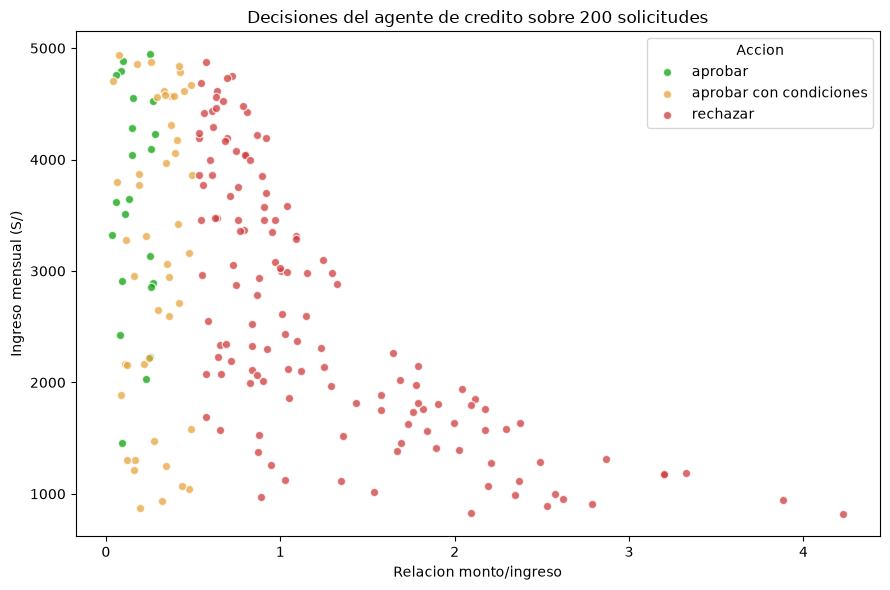

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200
ingresos = np.random.uniform(800, 5000, n)
montos = np.random.uniform(100, 4000, n)
morosos = np.random.choice([True, False], n)

acciones = []
for ing, mon, mor in zip(ingresos, montos, morosos):
    accion, _ = agente_credito(ing, mon, mor)
    acciones.append(accion)

acciones = np.array(acciones)
relaciones = montos / ingresos

colores = {"aprobar": "#0ca30c", "aprobar con condiciones": "#e8a33d", "rechazar": "#d03b3b"}

fig, ax = plt.subplots(figsize=(9, 6))
for accion in colores:
    mask = acciones == accion
    ax.scatter(relaciones[mask], ingresos[mask], label=accion, c=colores[accion], alpha=0.75, edgecolors="white")

ax.set_xlabel("Relacion monto/ingreso")
ax.set_ylabel("Ingreso mensual (S/)")
ax.set_title("Decisiones del agente de credito sobre 200 solicitudes")
ax.legend(title="Accion")
plt.tight_layout()
plt.show()